In [226]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [227]:
df = pd.read_csv("../data/emi_prediction_dataset.csv")
df.shape

C:\Users\HopeR\AppData\Local\Temp\ipykernel_29376\1075089013.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/emi_prediction_dataset.csv")


(404800, 27)

In [228]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404800 non-null  object 
 1   gender                  404800 non-null  object 
 2   marital_status          404800 non-null  object 
 3   education               402396 non-null  object 
 4   monthly_salary          404800 non-null  object 
 5   employment_type         404800 non-null  object 
 6   years_of_employment     404800 non-null  float64
 7   company_type            404800 non-null  object 
 8   house_type              404800 non-null  object 
 9   monthly_rent            402374 non-null  float64
 10  family_size             404800 non-null  int64  
 11  dependents              404800 non-null  int64  
 12  school_fees             404800 non-null  float64
 13  college_fees            404800 non-null  float64
 14  travel_expenses     

In [229]:
df.isnull().sum()

age                          0
gender                       0
marital_status               0
education                 2404
monthly_salary               0
employment_type              0
years_of_employment          0
company_type                 0
house_type                   0
monthly_rent              2426
family_size                  0
dependents                   0
school_fees                  0
college_fees                 0
travel_expenses              0
groceries_utilities          0
other_monthly_expenses       0
existing_loans               0
current_emi_amount           0
credit_score              2420
bank_balance              2426
emergency_fund            2351
emi_scenario                 0
requested_amount             0
requested_tenure             0
emi_eligibility              0
max_monthly_emi              0
dtype: int64

In [230]:
df.columns

Index(['age', 'gender', 'marital_status', 'education', 'monthly_salary',
       'employment_type', 'years_of_employment', 'company_type', 'house_type',
       'monthly_rent', 'family_size', 'dependents', 'school_fees',
       'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'emi_eligibility',
       'max_monthly_emi'],
      dtype='object')

In [231]:
df.dtypes.unique()

array([dtype('O'), dtype('float64'), dtype('int64')], dtype=object)

In [232]:
print(df.duplicated().sum())

0


In [233]:
df["emi_eligibility"].value_counts()

emi_eligibility
Not_Eligible    312868
Eligible         74444
High_Risk        17488
Name: count, dtype: int64

In [234]:
df["max_monthly_emi"].value_counts()

max_monthly_emi
500.00      106683
3080.00        513
4200.00        490
4620.00        479
6600.00        475
             ...  
17984.00         1
8503.88          1
33541.20         1
14201.60         1
19310.40         1
Name: count, Length: 15383, dtype: int64

In [235]:
df["age"].unique()

array([38.0, 58.0, 48.0, 32.0, 27.0, 47.0, 37.0, 31.0, 59.0, 49.0, 33.0,
       26.0, 39.0, 57.0, 28.0, '58', '38', '48', '32', '27', '37', '48.0',
       '33', '38.0', '49', '27.0', '31', '39', '47', '59', '32.0', '58.0',
       '57', '26', '28', '58.0.0', '39.0', '26.0', '37.0', '38.0.0',
       '32.0.0'], dtype=object)

In [236]:
df["age"] = pd.to_numeric(df["age"], errors="coerce")

In [237]:
df["age"].unique()

array([38., 58., 48., 32., 27., 47., 37., 31., 59., 49., 33., 26., 39.,
       57., 28., nan])

In [238]:
df["monthly_salary"].isnull().sum()

np.int64(0)

In [239]:
df["monthly_salary"] = pd.to_numeric(df["monthly_salary"], errors="coerce")

In [240]:
df["monthly_salary"].isnull().sum()

np.int64(1993)

In [241]:
df["bank_balance"].isnull().sum()

np.int64(2426)

In [242]:
df["bank_balance"] = pd.to_numeric(df["bank_balance"], errors="coerce")

In [243]:
df.isnull().sum()

age                          3
gender                       0
marital_status               0
education                 2404
monthly_salary            1993
employment_type              0
years_of_employment          0
company_type                 0
house_type                   0
monthly_rent              2426
family_size                  0
dependents                   0
school_fees                  0
college_fees                 0
travel_expenses              0
groceries_utilities          0
other_monthly_expenses       0
existing_loans               0
current_emi_amount           0
credit_score              2420
bank_balance              4392
emergency_fund            2351
emi_scenario                 0
requested_amount             0
requested_tenure             0
emi_eligibility              0
max_monthly_emi              0
dtype: int64

In [244]:
(df.isnull().sum() / len(df)) *100

age                       0.000741
gender                    0.000000
marital_status            0.000000
education                 0.593874
monthly_salary            0.492342
employment_type           0.000000
years_of_employment       0.000000
company_type              0.000000
house_type                0.000000
monthly_rent              0.599308
family_size               0.000000
dependents                0.000000
school_fees               0.000000
college_fees              0.000000
travel_expenses           0.000000
groceries_utilities       0.000000
other_monthly_expenses    0.000000
existing_loans            0.000000
current_emi_amount        0.000000
credit_score              0.597826
bank_balance              1.084980
emergency_fund            0.580781
emi_scenario              0.000000
requested_amount          0.000000
requested_tenure          0.000000
emi_eligibility           0.000000
max_monthly_emi           0.000000
dtype: float64

In [245]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404797 non-null  float64
 1   gender                  404800 non-null  object 
 2   marital_status          404800 non-null  object 
 3   education               402396 non-null  object 
 4   monthly_salary          402807 non-null  float64
 5   employment_type         404800 non-null  object 
 6   years_of_employment     404800 non-null  float64
 7   company_type            404800 non-null  object 
 8   house_type              404800 non-null  object 
 9   monthly_rent            402374 non-null  float64
 10  family_size             404800 non-null  int64  
 11  dependents              404800 non-null  int64  
 12  school_fees             404800 non-null  float64
 13  college_fees            404800 non-null  float64
 14  travel_expenses     

In [246]:
df["existing_loans"].unique()

array(['Yes', 'No'], dtype=object)

In [247]:
df["age"].unique()

array([38., 58., 48., 32., 27., 47., 37., 31., 59., 49., 33., 26., 39.,
       57., 28., nan])

In [248]:
print(df["age"].mean())
print(df["age"].median())
print(df["monthly_salary"].median())
print(df["monthly_salary"].mean())
print(df["credit_score"].mean())
print(df["credit_score"].median())
print(df["emergency_fund"].median())
print(df["emergency_fund"].mean())

38.87583158966099
38.0
51700.0
59509.3404980549
700.8562229733088
701.0
74000.0
96769.05173077832


In [249]:
num_cols = df.select_dtypes(include=["float64", "int64"]).columns
num_cols

Index(['age', 'monthly_salary', 'years_of_employment', 'monthly_rent',
       'family_size', 'dependents', 'school_fees', 'college_fees',
       'travel_expenses', 'groceries_utilities', 'other_monthly_expenses',
       'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund',
       'requested_amount', 'requested_tenure', 'max_monthly_emi'],
      dtype='object')

In [250]:
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\HopeR\AppData\Local\Temp\ipykernel_29376\4074283006.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [251]:
obj_cols = df.select_dtypes(include=["object"]).columns
obj_cols

Index(['gender', 'marital_status', 'education', 'employment_type',
       'company_type', 'house_type', 'existing_loans', 'emi_scenario',
       'emi_eligibility'],
      dtype='object')

In [252]:
for col in obj_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\HopeR\AppData\Local\Temp\ipykernel_29376\1679076907.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [253]:
df.isnull().sum()

age                       0
gender                    0
marital_status            0
education                 0
monthly_salary            0
employment_type           0
years_of_employment       0
company_type              0
house_type                0
monthly_rent              0
family_size               0
dependents                0
school_fees               0
college_fees              0
travel_expenses           0
groceries_utilities       0
other_monthly_expenses    0
existing_loans            0
current_emi_amount        0
credit_score              0
bank_balance              0
emergency_fund            0
emi_scenario              0
requested_amount          0
requested_tenure          0
emi_eligibility           0
max_monthly_emi           0
dtype: int64

In [254]:
df.select_dtypes(include=["float64", "int64"]).columns

Index(['age', 'monthly_salary', 'years_of_employment', 'monthly_rent',
       'family_size', 'dependents', 'school_fees', 'college_fees',
       'travel_expenses', 'groceries_utilities', 'other_monthly_expenses',
       'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund',
       'requested_amount', 'requested_tenure', 'max_monthly_emi'],
      dtype='object')

In [255]:
print(df["years_of_employment"].min())
print(df["years_of_employment"].max())

0.5
36.0


In [256]:
df.describe()

,age,monthly_salary,years_of_employment,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,current_emi_amount,credit_score,bank_balance,emergency_fund,requested_amount,requested_tenure,max_monthly_emi
count,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,4.048000e+05,404800.000000,4.048000e+05,404800.000000,404800.000000
mean,38.875825,59470.891843,5.364079,5793.516126,2.940425,1.940425,4624.575593,4066.253706,5687.497777,12804.999506,7119.309783,4543.407609,700.857083,2.411676e+05,96636.813488,3.708554e+05,29.126677,6763.602156
std,9.303538,43284.807915,6.079135,8634.376551,1.075199,1.075199,5061.074401,7319.344289,3392.671132,6993.853745,4510.447300,7034.901139,88.170806,1.822615e+05,81154.854810,3.451945e+05,18.100854,7741.263317
min,26.000000,3967.000000,0.500000,0.000000,1.000000,0.000000,0.000000,0.000000,600.000000,1800.000000,600.000000,0.000000,0.000000,6.100000e+03,1400.000000,1.000000e+04,3.000000,500.000000
25%,32.000000,35400.000000,1.200000,0.000000,2.000000,1.000000,0.000000,0.000000,3200.000000,7700.000000,3800.000000,0.000000,654.000000,1.053000e+05,38600.000000,1.240000e+05,15.000000,500.000000
50%,38.000000,51700.000000,3.200000,0.000000,3.000000,2.000000,3000.000000,0.000000,4900.000000,11400.000000,6000.000000,0.000000,701.000000,1.959000e+05,74000.000000,2.360000e+05,25.000000,4211.200000
75%,48.000000,72800.000000,7.200000,10600.000000,4.000000,3.000000,9000.000000,6500.000000,7400.000000,16400.000000,9300.000000,8000.000000,748.000000,3.292000e+05,130200.000000,4.940000e+05,40.000000,9792.000000
max,59.000000,499970.000000,36.000000,80000.000000,5.000000,4.000000,15000.000000,25000.000000,30300.000000,71200.000000,42900.000000,56300.000000,1200.000000,1.717300e+06,891500.000000,1.500000e+06,84.000000,91040.400000


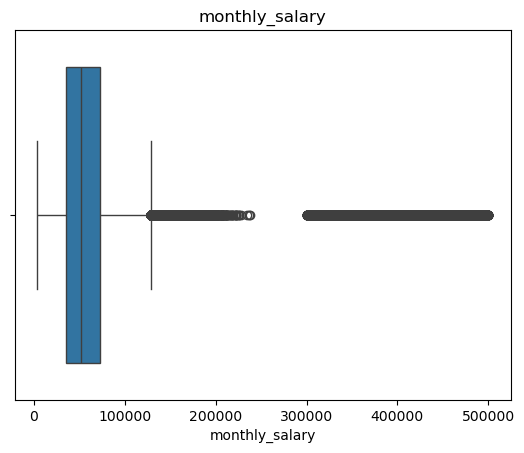

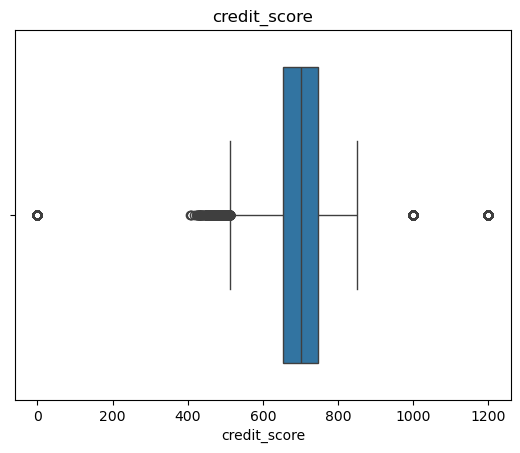

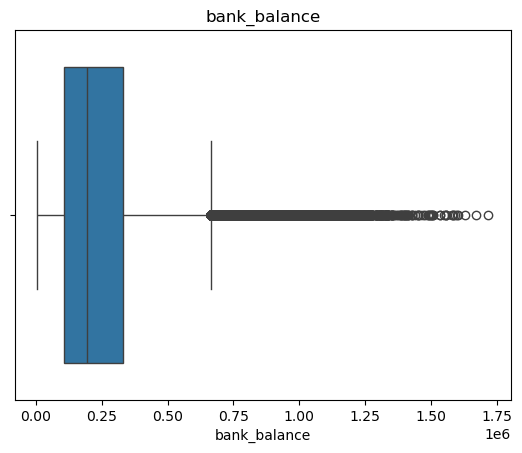

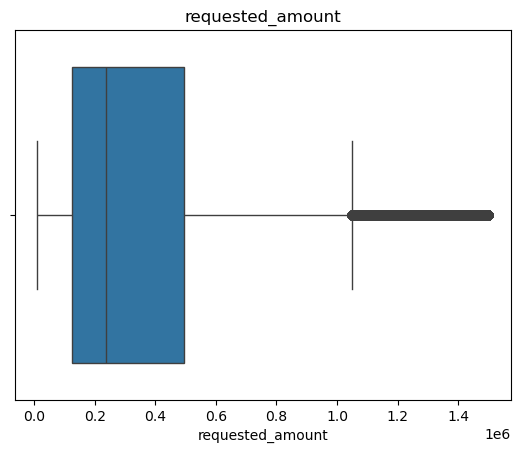

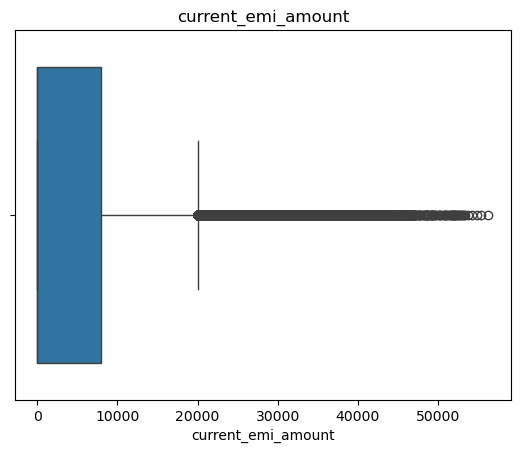

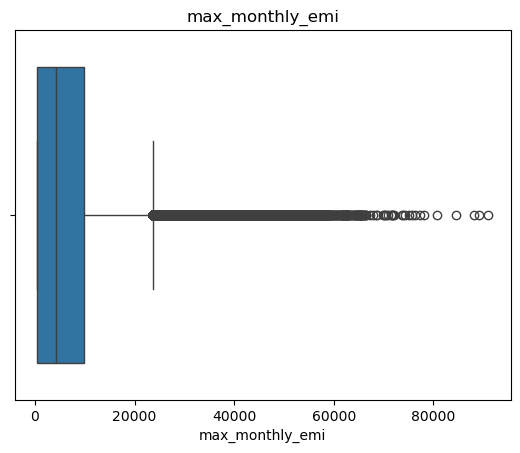

In [257]:
import seaborn as sns
import matplotlib.pyplot as plt


num_cols = [
    "monthly_salary",
    "credit_score",
    "bank_balance",
    "requested_amount",
    "current_emi_amount",
    "max_monthly_emi"
]

for col in num_cols:
    plt.figure()
    sns.boxplot(x= df[col])
    plt.title(col)
    plt.show()

In [258]:
print(df["credit_score"].min())
print(df["credit_score"].max())

0.0
1200.0


In [259]:
df["credit_score"] = df["credit_score"].clip(300, 900)

In [260]:
print(df["credit_score"].min())
print(df["credit_score"].max())

300.0
900.0


In [261]:
df.isnull().sum()

age                       0
gender                    0
marital_status            0
education                 0
monthly_salary            0
employment_type           0
years_of_employment       0
company_type              0
house_type                0
monthly_rent              0
family_size               0
dependents                0
school_fees               0
college_fees              0
travel_expenses           0
groceries_utilities       0
other_monthly_expenses    0
existing_loans            0
current_emi_amount        0
credit_score              0
bank_balance              0
emergency_fund            0
emi_scenario              0
requested_amount          0
requested_tenure          0
emi_eligibility           0
max_monthly_emi           0
dtype: int64

In [262]:
df[(df['age'] <= 25) & (df['age'] >= 60)]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi


In [263]:
df[df['monthly_salary'] < 0]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi


In [264]:
df['total_monthly_expenses'] = (
    df['monthly_rent'] +
    df['school_fees'] +
    df['college_fees'] +
    df['travel_expenses'] +
    df['groceries_utilities'] +
    df['other_monthly_expenses'] +
    df['current_emi_amount']
)

In [265]:
df['debt_to_income_ratio'] = df['current_emi_amount'] / df['monthly_salary']
df['expense_to_income_ratio'] = df['total_monthly_expenses'] / df['monthly_salary']
df['affordability_ratio'] = (df['monthly_salary'] - df['total_monthly_expenses']) / df['monthly_salary']

In [266]:
df[["debt_to_income_ratio","expense_to_income_ratio","affordability_ratio"]].describe()

,debt_to_income_ratio,expense_to_income_ratio,affordability_ratio
count,404800.000000,404800.000000,404800.000000
mean,0.083594,0.867187,0.132813
std,0.142263,0.636534,0.636534
min,0.000000,0.011144,-30.291979
25%,0.000000,0.606769,0.008796
50%,0.000000,0.779123,0.220877
75%,0.174422,0.991204,0.393231
max,7.704465,31.291979,0.988856


In [267]:
df.shape

(404800, 31)

In [268]:
df = df[df['expense_to_income_ratio'] <= 2]
df['debt_to_income_ratio'] = df['debt_to_income_ratio'].clip(0, 1)
df['expense_to_income_ratio'] = df['expense_to_income_ratio'].clip(0, 2)
df['affordability_ratio'] = df['affordability_ratio'].  clip(-1, 1)

In [269]:
df.shape

(398455, 31)

In [270]:
df[["debt_to_income_ratio","expense_to_income_ratio","affordability_ratio"]].describe()

,debt_to_income_ratio,expense_to_income_ratio,affordability_ratio
count,398455.000000,398455.000000,398455.000000
mean,0.079049,0.813913,0.186087
std,0.104408,0.300033,0.300033
min,0.000000,0.011144,-1.000000
25%,0.000000,0.603774,0.021827
50%,0.000000,0.773613,0.226387
75%,0.173303,0.978173,0.396226
max,0.802830,2.000000,0.988856


In [ ]:
#df.to_csv("../data/emi_prediction_dataset_cleaned.csv", index=False)

In [283]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 398455 entries, 0 to 404799
Data columns (total 31 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   age                      398455 non-null  float64
 1   gender                   398455 non-null  object 
 2   marital_status           398455 non-null  object 
 3   education                398455 non-null  object 
 4   monthly_salary           398455 non-null  float64
 5   employment_type          398455 non-null  object 
 6   years_of_employment      398455 non-null  float64
 7   company_type             398455 non-null  object 
 8   house_type               398455 non-null  object 
 9   monthly_rent             398455 non-null  float64
 10  family_size              398455 non-null  int64  
 11  dependents               398455 non-null  int64  
 12  school_fees              398455 non-null  float64
 13  college_fees             398455 non-null  float64
 14  travel_ex

In [284]:
df.columns

Index(['age', 'gender', 'marital_status', 'education', 'monthly_salary',
       'employment_type', 'years_of_employment', 'company_type', 'house_type',
       'monthly_rent', 'family_size', 'dependents', 'school_fees',
       'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'emi_eligibility',
       'max_monthly_emi', 'total_monthly_expenses', 'debt_to_income_ratio',
       'expense_to_income_ratio', 'affordability_ratio'],
      dtype='object')